# 03 — Self-Play Demo

One complete self-play game with the current `SelfPlayWorker`: the network is wrapped
as `net_fn`, PUCT-MCTS selects each move, and the recorder inside the worker turns the
game into `(state, policy, z)` training samples — the data everything downstream
(replay buffer, training loop) is built on.

`max_moves` keeps the demo short; runtime is a few seconds on CPU.

In [1]:
import numpy as np
import torch

from leelax.net.model import LeelaXNet
from leelax.selfplay.worker import SelfPlayWorker

torch.manual_seed(0)
np.random.seed(0)

net = LeelaXNet()
net.eval()

def net_fn(x):
    with torch.no_grad():
        return net(x)

# tau_moves = number of exploratory (sampled) opening plies
worker = SelfPlayWorker(net_fn, n_simulations=24, max_moves=60, tau_moves=8)
samples, moves = worker.play_game(verbose=True)

[1] h2h4 (h4)
[2] f7f6 (f6)
[3] c2c4 (c4)
[4] h7h6 (h6)
[5] d2d4 (d4)
[6] g7g5 (g5)
[7] e1d2 (Kd2)


[8] b7b6 (b6)
[9] h1h3 (Rh3)
[10] e8f7 (Kf7)
[11] b1c3 (Nc3)
[12] c7c6 (c6)


[13] a1b1 (Rb1)
[14] h8h7 (Rh7)
[15] b1a1 (Ra1)
[16] d7d5 (d5)
[17] a1b1 (Rb1)


[18] d8c7 (Qc7)
[19] b1a1 (Ra1)
[20] c7h2 (Qh2)


[21] a1b1 (Rb1)
[22] h2h1 (Qh1)
[23] b1a1 (Ra1)
[24] h1g1 (Qxg1)


...

[46] a1c1 (Rxc1)
[47] g2d5 (Bxd5+)
[48] c8e6 (Be6)


[49] b2b3 (b3)
[50] g7g6 (Rg6)
[51] b5b8 (Qxb8)


[52] a8b8 (Rxb8)
[53] d5h1 (Bh1)
[54] b8b7 (Rb7)


[55] h1g2 (Bg2)
[56] b7b6 (Rb6)
[57] g2e4 (Be4)


[58] b6b5 (Rb5)
[59] e4d5 (Bd5)
[60] b5b4 (Rb4)


In [2]:
s, pi, z = samples[0]
print("plies played:     ", len(moves))
print("training samples: ", len(samples))
print("state:", tuple(s.shape), "| policy:", pi.shape, "| z (white POV):", z)

plies played:      60
training samples:  60
state: (24, 8, 8) | policy: (4864,) | z (white POV): 0.0


The policy target of a sample is the MCTS visit distribution, not the raw network
output. Below: the top moves the search preferred in the starting position.

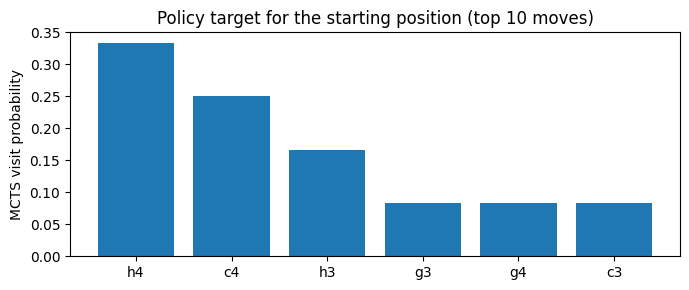

In [3]:
import chess
import matplotlib.pyplot as plt

from leelax.env.policy_index import index_to_move

board = chess.Board()
pi0 = samples[0][1]
top = [int(i) for i in np.argsort(pi0)[::-1] if pi0[i] > 0][:10]
labels = [board.san(index_to_move(board, i)) for i in top]

plt.figure(figsize=(7, 3))
plt.bar(labels, pi0[top])
plt.ylabel("MCTS visit probability")
plt.title("Policy target for the starting position (top 10 moves)")
plt.tight_layout()
plt.show()